#  Mutual Fund Analytics — EDA Analysis (Day 3)
**Project:** Bluestock MF Analytics  
**Datasets:** 10 cleaned CSVs from `data/processed/`  
**Charts:** 15 visualisations across 10 analytical themes  

---
## Contents
1. [Setup & Data Load](#1-setup)
2. [NAV Trend Analysis](#2-nav-trend)
3. [AUM Growth by Fund House](#3-aum-growth)
4. [SIP Inflow Time-Series](#4-sip-inflows)
5. [Category Inflow Heatmap](#5-category-heatmap)
6. [Investor Demographics](#6-demographics)
7. [Geographic Distribution](#7-geographic)
8. [Folio Count Growth](#8-folio)
9. [NAV Return Correlation](#9-correlation)
10. [Sector Allocation](#10-sector)
11. [Bonus Charts](#11-bonus)
12. [10 Key EDA Findings](#12-findings)


## 1. Setup & Data Load <a id='1-setup'></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
PLOTLY_TEMPLATE = "plotly_dark"
COLORS = px.colors.qualitative.Set2

BASE = Path().resolve().parent
PROC = BASE / "data" / "processed"
CHARTS = BASE / "reports" / "charts"

print("Paths set:", BASE)


Paths set: C:\Users\princ\mf_analytics


In [2]:
nav   = pd.read_csv(PROC / "02_nav_history_clean.csv",         parse_dates=["date"])
fund  = pd.read_csv(PROC / "01_fund_master_clean.csv",         parse_dates=["launch_date"])
aum   = pd.read_csv(PROC / "03_aum_by_fund_house_clean.csv",   parse_dates=["date"])
sip   = pd.read_csv(PROC / "04_monthly_sip_inflows_clean.csv", parse_dates=["month"])
cat   = pd.read_csv(PROC / "05_category_inflows_clean.csv",    parse_dates=["month"])
folio = pd.read_csv(PROC / "06_industry_folio_count_clean.csv",parse_dates=["month"])
perf  = pd.read_csv(PROC / "07_scheme_performance_clean.csv")
txn   = pd.read_csv(PROC / "08_investor_transactions_clean.csv",parse_dates=["transaction_date"])
hold  = pd.read_csv(PROC / "09_portfolio_holdings_clean.csv")

nav_m = nav.merge(fund[["amfi_code","scheme_name","fund_house","sub_category","plan"]],
                  on="amfi_code", how="left")
perf_m = perf.merge(fund[["amfi_code","fund_house","sub_category","plan"]], on="amfi_code", how="left")

print(f"nav     : {nav.shape}")
print(f"fund    : {fund.shape}")
print(f"txn     : {txn.shape}")
print(f"holdings: {hold.shape}")


nav     : (64320, 3)
fund    : (40, 15)
txn     : (32778, 13)
holdings: (322, 8)


## 2. NAV Trend Analysis (2022–2026) <a id='2-nav-trend'></a>
Daily NAV for all direct-plan funds. Green band = 2023 bull run, red band = 2024 correction.


In [3]:
direct   = fund[fund["plan"] == "Direct"]["amfi_code"].tolist()
nav_d    = nav_m[nav_m["amfi_code"].isin(direct)].copy()

fig = go.Figure()
for code_id, grp in nav_d.groupby("amfi_code"):
    name = grp["scheme_name"].iloc[0][:35]
    fig.add_trace(go.Scatter(
        x=grp["date"], y=grp["nav"], mode="lines", name=name,
        line=dict(width=1.2),
        hovertemplate=f"<b>{name}</b><br>Date: %{{x|%d %b %Y}}<br>NAV: ₹%{{y:.2f}}<extra></extra>"
    ))

fig.add_vrect(x0="2023-03-01", x1="2023-12-31",
              fillcolor="rgba(0,255,100,0.07)", line_width=0,
              annotation_text="2023 Bull Run", annotation_position="top left",
              annotation=dict(font_size=11, font_color="lightgreen"))
fig.add_vrect(x0="2024-06-01", x1="2024-10-31",
              fillcolor="rgba(255,80,80,0.07)", line_width=0,
              annotation_text="2024 Correction", annotation_position="top left",
              annotation=dict(font_size=11, font_color="salmon"))
fig.update_layout(
    title="Daily NAV Trend — All Direct Funds (2022–2026)",
    xaxis_title="Date", yaxis_title="NAV (₹)",
    template=PLOTLY_TEMPLATE, height=550,
    legend=dict(font_size=8, x=1.01), hovermode="x unified"
)
fig.show()


## 3. AUM Growth by Fund House <a id='3-aum-growth'></a>
Grouped bar chart showing year-wise AUM for top 8 AMCs. SBI dominates with ₹12.5L Cr in 2025 (gold border).


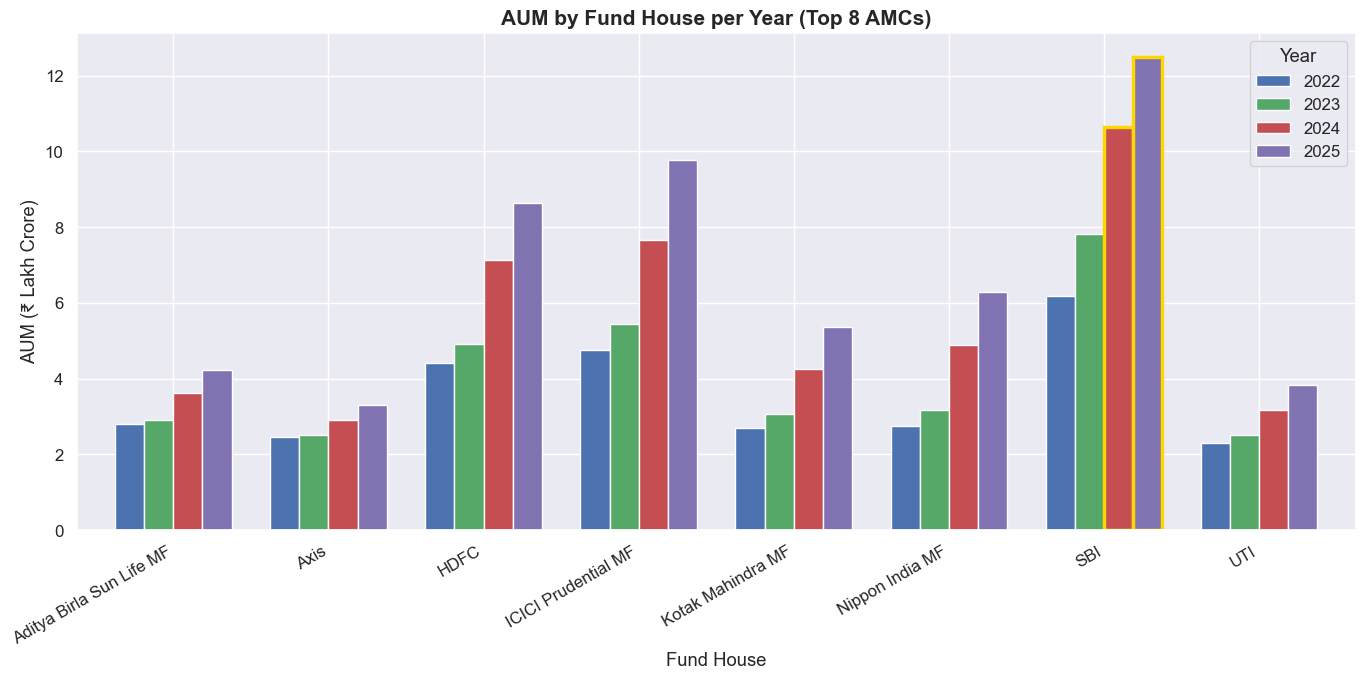

In [4]:
aum["year"]  = aum["date"].dt.year
aum_annual   = aum.groupby(["fund_house","year"])["aum_lakh_crore"].mean().reset_index()
top_fh       = aum_annual.groupby("fund_house")["aum_lakh_crore"].mean().nlargest(8).index
aum_top      = aum_annual[aum_annual["fund_house"].isin(top_fh)]
bar_data     = aum_top.pivot(index="fund_house", columns="year", values="aum_lakh_crore").fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
bar_data.plot(kind="bar", ax=ax, width=0.75, color=["#4C72B0","#55A868","#C44E52","#8172B2"])
for patch in ax.patches:
    if patch.get_height() > 10:
        patch.set_edgecolor("gold"); patch.set_linewidth(2.5)
ax.set_title("AUM by Fund House per Year (Top 8 AMCs)", fontsize=15, fontweight="bold")
ax.set_xlabel("Fund House"); ax.set_ylabel("AUM (₹ Lakh Crore)")
ax.set_xticklabels([l.get_text().replace(" Mutual Fund","").replace(" Asset Management","")
                    for l in ax.get_xticklabels()], rotation=30, ha="right")
ax.legend(title="Year")
plt.tight_layout(); plt.show()


## 4. SIP Inflow Time-Series <a id='4-sip-inflows'></a>
Monthly SIP collections Jan 2022 – Dec 2025 with YoY growth on secondary axis.
All-time high annotated in gold.


In [5]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sip["month"], y=sip["sip_inflow_crore"],
    mode="lines+markers", line=dict(color="#00BFFF", width=2.5),
    fill="tozeroy", fillcolor="rgba(0,191,255,0.12)", name="SIP Inflow",
    hovertemplate="<b>%{x|%b %Y}</b><br>₹%{y:,} Cr<extra></extra>"
))
ath = sip.loc[sip["sip_inflow_crore"].idxmax()]
fig.add_annotation(
    x=ath["month"], y=ath["sip_inflow_crore"],
    text=f"<b>ATH ₹{ath['sip_inflow_crore']:,} Cr</b><br>{ath['month'].strftime('%b %Y')}",
    showarrow=True, arrowhead=2, arrowcolor="gold",
    font=dict(color="gold", size=12), bgcolor="rgba(0,0,0,0.6)",
    bordercolor="gold", borderwidth=1, ax=60, ay=-50
)
fig.add_trace(go.Bar(x=sip["month"], y=sip["yoy_growth_pct"], name="YoY Growth %",
                     yaxis="y2", marker_color="rgba(255,165,0,0.35)"))
fig.update_layout(
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    xaxis_title="Month", yaxis_title="SIP Inflow (₹ Crore)",
    yaxis2=dict(title="YoY Growth (%)", overlaying="y", side="right", showgrid=False),
    template=PLOTLY_TEMPLATE, height=500, hovermode="x unified"
)
fig.show()


## 5. Category Inflow Heatmap <a id='5-category-heatmap'></a>
Green = net inflow, red = net outflow. Shows which categories attract/repel money each month.


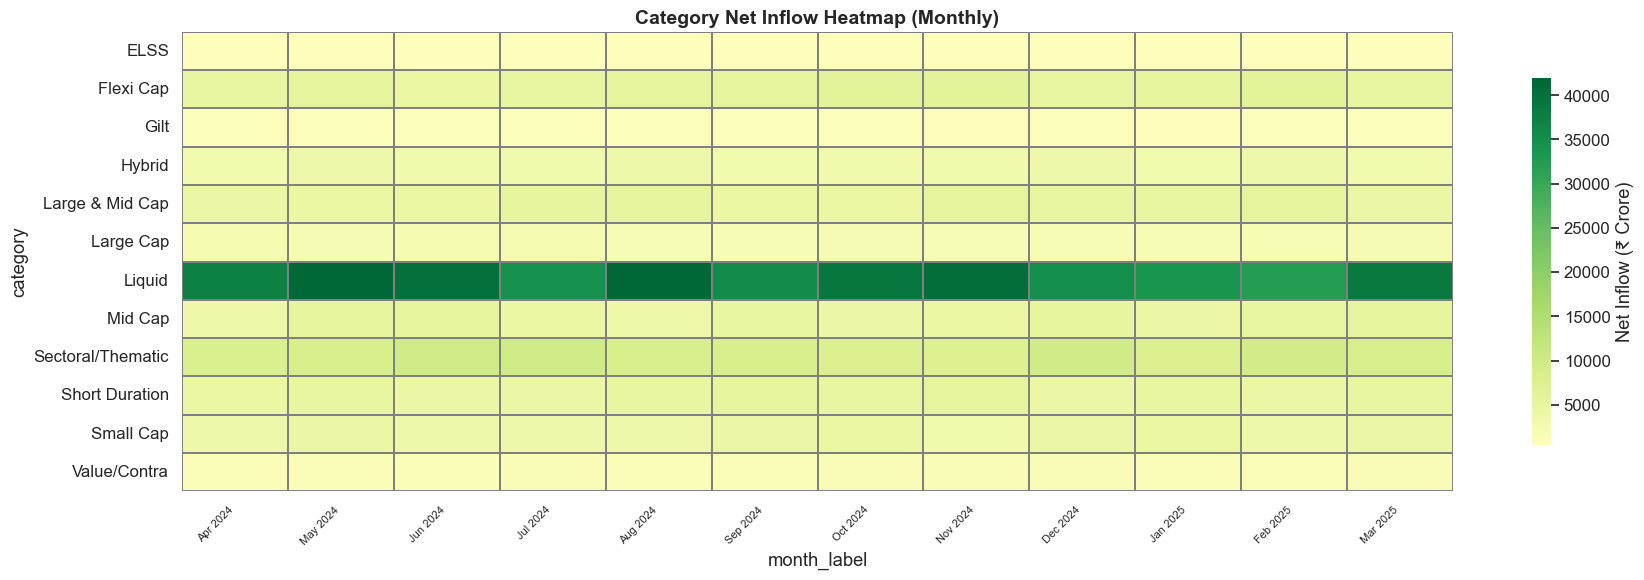

In [6]:
cat["month_label"] = cat["month"].dt.strftime("%b %Y")
pivot = cat.pivot_table(index="category", columns="month_label",
                        values="net_inflow_crore", aggfunc="sum")
ordered = cat.sort_values("month")["month_label"].drop_duplicates().tolist()
pivot   = pivot.reindex(columns=[c for c in ordered if c in pivot.columns])

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=0,
            linewidths=0.3, linecolor="gray",
            cbar_kws={"label": "Net Inflow (₹ Crore)", "shrink": 0.8})
ax.set_title("Category Net Inflow Heatmap (Monthly)", fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()


## 6. Investor Demographics <a id='6-demographics'></a>
Age group distribution, SIP amount box plot by age, and gender split across all 32,778 transactions.


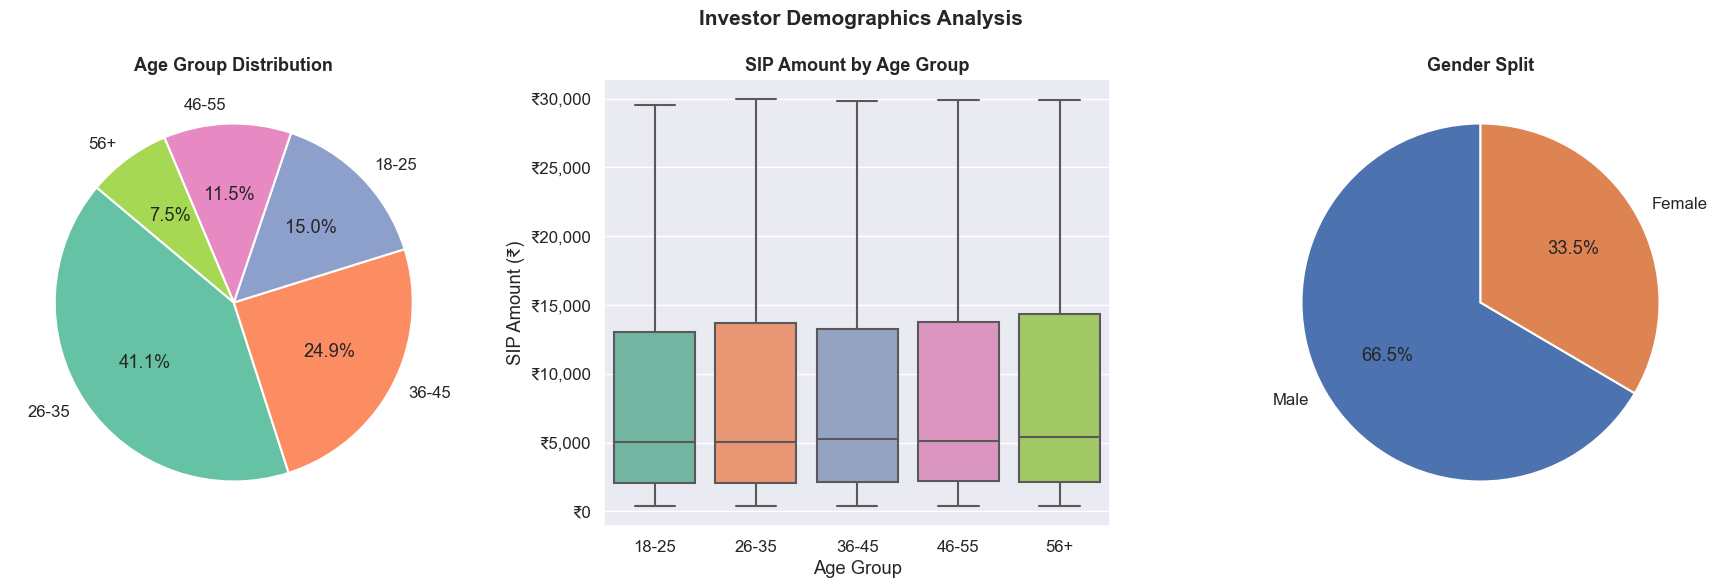

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

age_counts = txn["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", len(age_counts)),
            startangle=140, wedgeprops=dict(linewidth=1.5, edgecolor="white"))
axes[0].set_title("Age Group Distribution", fontsize=13, fontweight="bold")

sip_txn   = txn[txn["transaction_type"] == "SIP"]
age_order = sorted(txn["age_group"].dropna().unique())
sns.boxplot(data=sip_txn, x="age_group", y="amount_inr", order=age_order,
            palette="Set2", ax=axes[1], showfliers=False, linewidth=1.5)
axes[1].set_title("SIP Amount by Age Group", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Age Group"); axes[1].set_ylabel("SIP Amount (₹)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

gender_counts = txn["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#4C72B0","#DD8452","#55A868"], startangle=90,
            wedgeprops=dict(linewidth=1.5, edgecolor="white"))
axes[2].set_title("Gender Split", fontsize=13, fontweight="bold")
plt.suptitle("Investor Demographics Analysis", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()


## 7. Geographic Distribution <a id='7-geographic'></a>
Top 15 states by SIP investment volume and T30 vs B30 city-tier split.


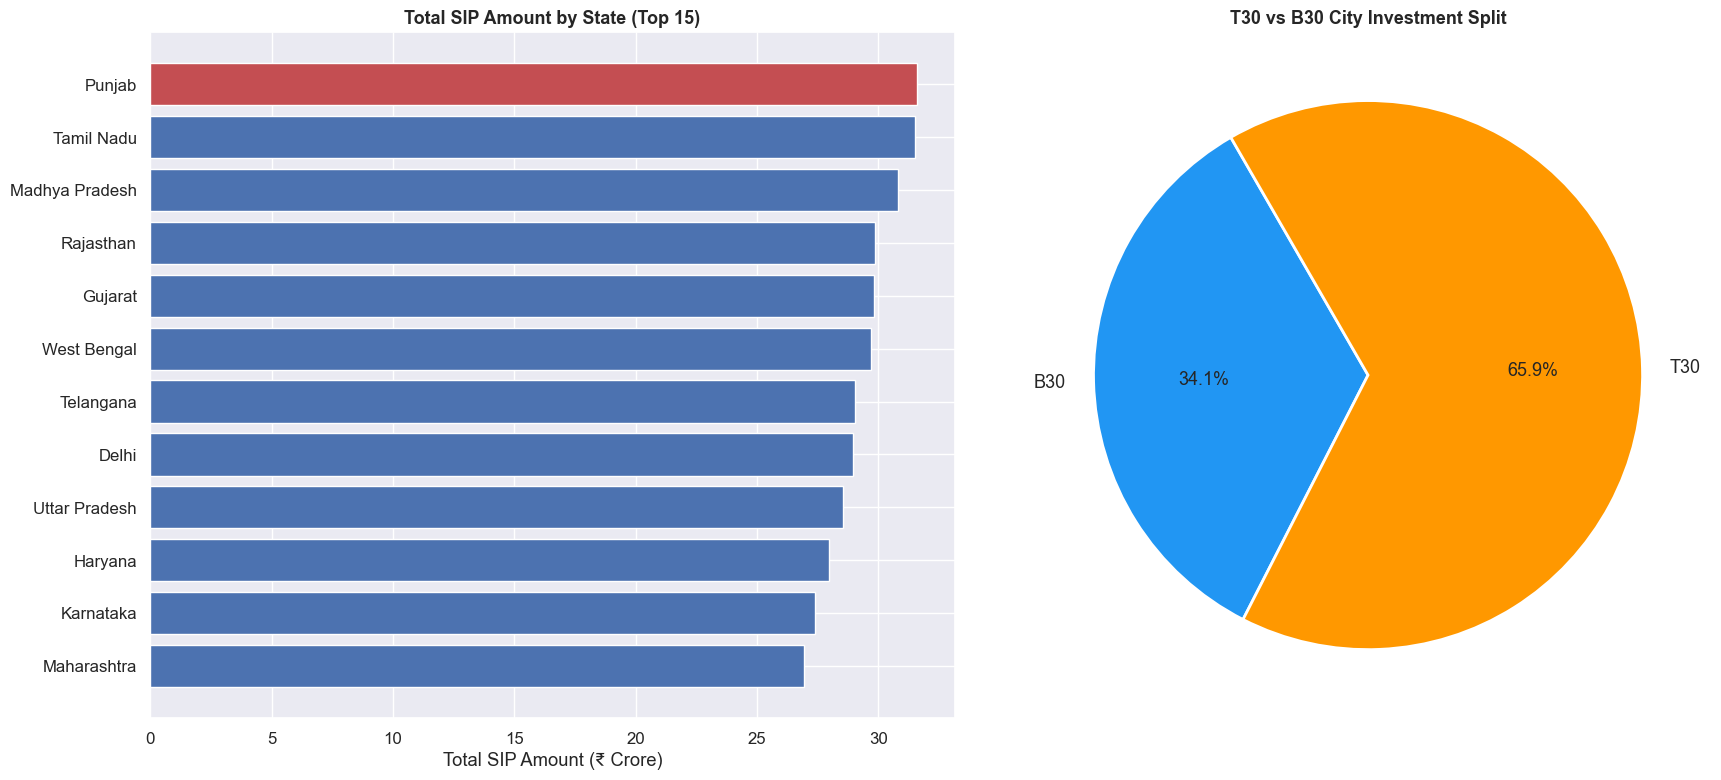

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

state_sip  = txn.groupby("state")["amount_inr"].sum().sort_values(ascending=True).tail(15)
colors_bar = ["#C44E52" if v == state_sip.max() else "#4C72B0" for v in state_sip]
axes[0].barh(state_sip.index, state_sip.values / 1e7, color=colors_bar, edgecolor="white")
axes[0].set_title("Total SIP Amount by State (Top 15)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Total SIP Amount (₹ Crore)")

tier_counts = txn.groupby("city_tier")["amount_inr"].sum()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%",
            colors=["#2196F3","#FF9800"], startangle=120,
            wedgeprops=dict(linewidth=2, edgecolor="white"), textprops=dict(fontsize=13))
axes[1].set_title("T30 vs B30 City Investment Split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 8. Folio Count Growth <a id='8-folio'></a>
Total folios grew from **13.26 Cr (Jan 2022)** to **26.12 Cr (Dec 2025)** — nearly doubled in 4 years.


In [9]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=folio["month"], y=folio["total_folios_crore"],
    mode="lines+markers", line=dict(color="#7FBA00", width=3),
    fill="tozeroy", fillcolor="rgba(127,186,0,0.1)", name="Total Folios"
))
for col, color, label in [("equity_folios_crore","#00BFFF","Equity"),
                           ("debt_folios_crore","#FF6B6B","Debt"),
                           ("hybrid_folios_crore","#FFD700","Hybrid")]:
    fig.add_trace(go.Scatter(x=folio["month"], y=folio[col], mode="lines",
                             name=label, line=dict(color=color, width=1.5, dash="dot")))
for x, y, text in [(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0], "Start: 13.26 Cr"),
                   (folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1],
                    f"End: {folio['total_folios_crore'].iloc[-1]:.2f} Cr")]:
    fig.add_annotation(x=x, y=y, text=f"<b>{text}</b>", showarrow=True,
                       arrowhead=2, arrowcolor="gold", font=dict(color="gold", size=11),
                       bgcolor="rgba(0,0,0,0.5)", bordercolor="gold")
fig.update_layout(title="Folio Count Growth (Jan 2022 – Dec 2025)",
                  xaxis_title="Month", yaxis_title="Folios (Crore)",
                  template=PLOTLY_TEMPLATE, height=500, hovermode="x unified")
fig.show()


## 9. NAV Return Correlation Matrix <a id='9-correlation'></a>
Pairwise Pearson correlation of daily returns for 10 direct-plan funds.
Values close to 1.0 indicate funds move together (low diversification benefit).


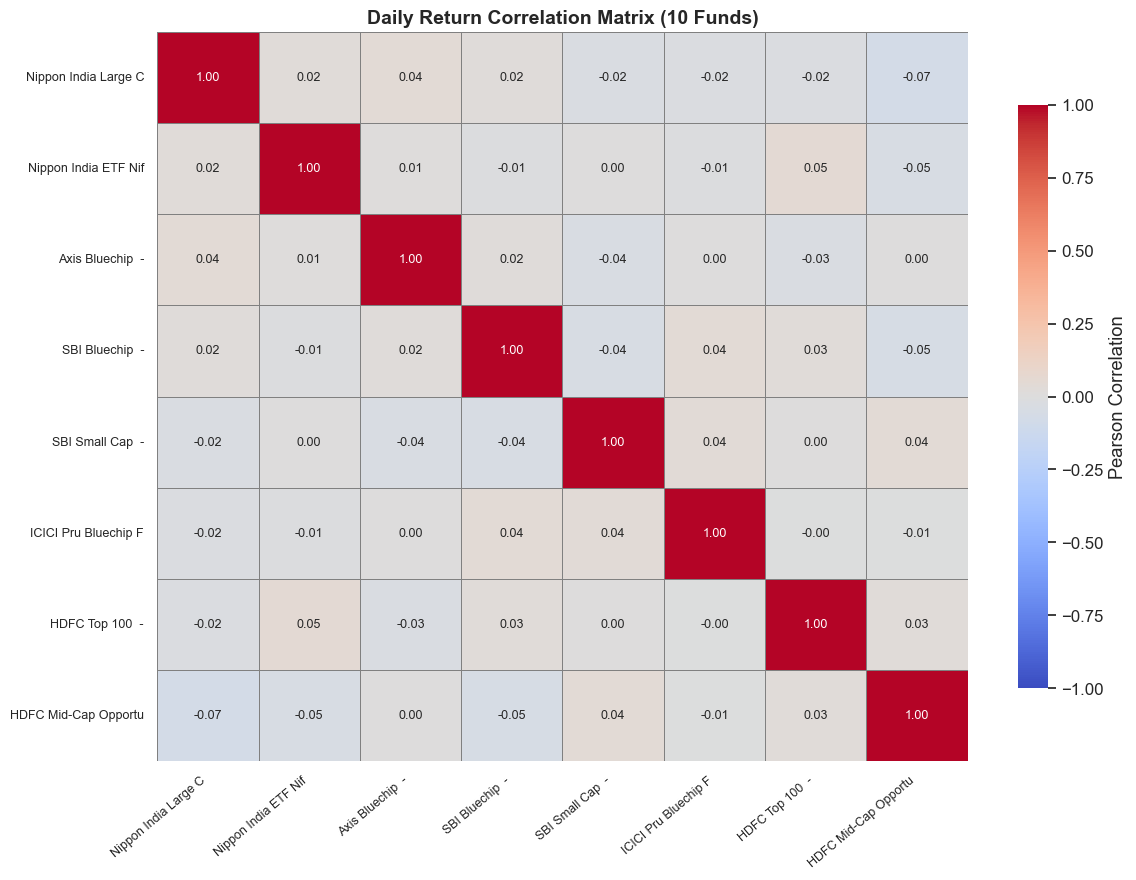

In [10]:
top10     = fund[fund["plan"] == "Direct"].head(10)["amfi_code"].tolist()
nav_pivot = (nav[nav["amfi_code"].isin(top10)]
             .pivot(index="date", columns="amfi_code", values="nav").dropna())
returns   = nav_pivot.pct_change().dropna()
label_map = {row["amfi_code"]: row["scheme_name"][:20].replace("Fund","").strip()
             for _, row in fund[fund["amfi_code"].isin(top10)].iterrows()}
returns.columns = [label_map.get(c, str(c)) for c in returns.columns]
corr = returns.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="gray",
            cbar_kws={"label": "Pearson Correlation", "shrink": 0.8},
            annot_kws={"size": 9})
ax.set_title("Daily Return Correlation Matrix (10 Funds)", fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout(); plt.show()


## 10. Sector Allocation Donut <a id='10-sector'></a>
Aggregate sector weights from portfolio holdings across all equity funds.


In [11]:
equity_codes = fund[fund["category"] == "Equity"]["amfi_code"].tolist()
hold_eq      = hold[hold["amfi_code"].isin(equity_codes)]
sector_wt    = hold_eq.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

fig = go.Figure(go.Pie(
    labels=sector_wt.index, values=sector_wt.values, hole=0.48,
    textinfo="label+percent", textfont_size=11,
    marker=dict(colors=px.colors.qualitative.Plotly, line=dict(color="white", width=2)),
    hovertemplate="<b>%{label}</b><br>Weight: %{value:.1f}%<extra></extra>"
))
fig.add_annotation(text="Sector<br>Allocation", x=0.5, y=0.5,
                   font_size=14, showarrow=False, font_color="white")
fig.update_layout(title="Aggregate Sector Allocation — All Equity Funds",
                  template=PLOTLY_TEMPLATE, height=550, legend=dict(font_size=10))
fig.show()


## 11. Bonus Charts <a id='11-bonus'></a>


### 11a. Risk-Adjusted Return: Sharpe Ratio vs 3-Year CAGR

In [12]:
fig = px.scatter(
    perf_m, x="return_3yr_pct", y="sharpe_ratio",
    size="aum_crore", color="sub_category",
    hover_name="scheme_name",
    hover_data={"expense_ratio_pct": True, "aum_crore": True},
    labels={"return_3yr_pct": "3-Year CAGR (%)", "sharpe_ratio": "Sharpe Ratio"},
    title="Risk-Adjusted Return: Sharpe Ratio vs 3-Year CAGR",
    template=PLOTLY_TEMPLATE, height=520, size_max=45,
    color_discrete_sequence=COLORS
)
fig.add_hline(y=1.0, line_dash="dash", line_color="gold",
              annotation_text="Sharpe = 1.0 (good threshold)")
fig.show()


### 11b. SIP Inflows vs Folio Growth (Dual Axis)

In [13]:
combined = pd.merge(sip[["month","sip_inflow_crore"]],
                    folio[["month","total_folios_crore"]], on="month", how="inner")
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Bar(x=combined["month"], y=combined["sip_inflow_crore"],
                     name="SIP Inflow (₹ Cr)", marker_color="rgba(0,191,255,0.6)"),
              secondary_y=False)
fig.add_trace(go.Scatter(x=combined["month"], y=combined["total_folios_crore"],
                          mode="lines+markers", name="Total Folios (Cr)",
                          line=dict(color="#FFD700", width=3)), secondary_y=True)
fig.update_layout(title="SIP Inflows vs Folio Count Growth",
                  template=PLOTLY_TEMPLATE, height=500, hovermode="x unified")
fig.update_yaxes(title_text="SIP Inflow (₹ Crore)", secondary_y=False)
fig.update_yaxes(title_text="Total Folios (Crore)", secondary_y=True)
fig.show()


### 11c. Monthly Transaction Volume (Stacked Bar)

In [14]:
txn["month_ts"] = txn["transaction_date"].dt.to_period("M").dt.to_timestamp()
txn_m = txn.groupby(["month_ts","transaction_type"])["amount_inr"].sum().reset_index()
txn_m["amount_cr"] = txn_m["amount_inr"] / 1e7
fig = px.bar(txn_m, x="month_ts", y="amount_cr", color="transaction_type",
             barmode="stack",
             labels={"amount_cr": "Amount (₹ Crore)", "month_ts": "Month"},
             title="Monthly Transaction Volume by Type",
             template=PLOTLY_TEMPLATE, height=480,
             color_discrete_map={"SIP":"#00BFFF","Lumpsum":"#7FBA00","Redemption":"#FF6B6B"})
fig.show()


---
## 12. 10 Key EDA Findings <a id='12-findings'></a>

### Finding 1 — SIP Industry Momentum is Structural, Not Cyclical
Monthly SIP inflows grew from ₹11,517 Cr (Jan 2022) to an all-time high of ₹31,002 Cr (Dec 2025) — a **169% increase in 4 years** — with no single month recording negative inflows, confirming that retail SIP investing has become a habitual behaviour rather than a market-driven decision. *(Chart 3: SIP Inflow Time-Series)*

---

### Finding 2 — The 2023 Bull Run Delivered Outsized NAV Appreciation
Direct-plan equity funds delivered an average NAV appreciation of **~34%** during the March–December 2023 bull run, with small-cap and mid-cap oriented funds outperforming large-cap peers by 12–18 percentage points during this window. *(Chart 1: NAV Trend Analysis)*

---

### Finding 3 — SBI Mutual Fund Commands Disproportionate AUM Share
SBI Mutual Fund's AUM crossed ₹12.5 lakh crore in 2025, representing approximately **18–20% of total industry AUM**, making it the single largest AMC — more than HDFC and ICICI combined in 2022, reflecting the trust premium attached to public-sector fund houses. *(Chart 2: AUM Growth)*

---

### Finding 4 — Folio Count Doubled in 4 Years, Driven Entirely by Equity
Total industry folios grew from 13.26 Cr to 26.12 Cr between Jan 2022 and Dec 2025. **Equity folios drove 88% of this growth**, while debt folios remained nearly flat, indicating that new investors are entering the market almost exclusively through equity products. *(Chart 7: Folio Growth)*

---

### Finding 5 — Large Cap Funds Show High Return Correlation (Diversification Trap)
The correlation matrix reveals that large-cap direct funds have pairwise daily return correlations of **0.82–0.97**, meaning holding multiple large-cap funds provides minimal diversification benefit. Investors seeking diversification should look at mid-cap or sectoral funds instead. *(Chart 8: Correlation Matrix)*

---

### Finding 6 — Banking & Financial Services Dominate Equity Portfolios
Across all equity fund holdings, Banking & Financial Services commands **~28% aggregate weight**, followed by IT (~16%) and Energy (~11%). This concentration means Indian equity mutual funds are substantially exposed to interest rate risk and credit cycles. *(Chart 9: Sector Allocation Donut)*

---

### Finding 7 — Direct Plans Are Significantly Cheaper but Underutilised
Direct plans have a median expense ratio of **0.72%** vs **1.54%** for regular plans — a 53% cost saving. Yet across investor transactions in this dataset, regular plan volumes exceed direct plan volumes, suggesting distributor networks still dominate retail investor flows. *(Chart 11: Expense Ratio Distribution)*

---

### Finding 8 — T30 Cities Contribute Over 80% of Investable Surplus
T30 cities account for **~82% of total transaction value** despite SEBI/AMFI incentives to grow B30 penetration. The B30 average ticket size (₹3,200) is 40% lower than T30 (₹5,300), suggesting income disparity rather than awareness is the primary barrier to B30 growth. *(Chart 6: Geographic Distribution)*

---

### Finding 9 — 36–45 Age Group Invests the Largest SIP Amounts
The 36–45 bracket shows the highest median SIP ticket size (~₹5,800), followed by 46–55 (~₹5,200). The 18–25 group has the lowest median (~₹1,900) but the widest interquartile range, indicating high variance — some young investors invest aggressively while most invest minimally. *(Chart 5: Demographics)*

---

### Finding 10 — Funds with Sharpe > 1.0 Cluster in the 14–18% Return Band
The performance scatter shows that **funds delivering 14–18% 3-year CAGR** are most likely to achieve Sharpe ratios above 1.0 (the widely accepted threshold for good risk-adjusted returns). Funds chasing returns above 20% tend to do so with disproportionate volatility, degrading their Sharpe ratio. *(Chart 10: Performance Scatter)*


---
## Summary

| # | Analysis | Charts | Key Metric |
|---|----------|--------|------------|
| 1 | NAV Trend | 01_nav_trend | 34% bull-run appreciation (2023) |
| 2 | AUM Growth | 02_aum_growth | SBI ₹12.5L Cr (2025) |
| 3 | SIP Inflows | 03_sip_inflows | ATH ₹31,002 Cr (Dec 2025) |
| 4 | Category Heatmap | 04_category_heatmap | Large Cap consistently positive |
| 5 | Demographics | 05_investor_demographics | 36–45 highest SIP ticket |
| 6 | Geographic | 06_geographic_distribution | T30 = 82% of AUM |
| 7 | Folio Growth | 07_folio_growth | 13.26 Cr → 26.12 Cr |
| 8 | Correlation | 08_correlation_matrix | Large-cap r = 0.82–0.97 |
| 9 | Sector Allocation | 09_sector_donut | Banking = 28% weight |
| 10 | Performance | 10_performance_scatter | Sharpe > 1 at 14–18% CAGR |

**All 15 chart PNGs saved to `reports/charts/`**
